In [ ]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from google.colab import files

# -------- UPLOAD FILES IN COLAB --------

# Upload Fake.csv
print("Upload Fake.csv")
uploaded_fake = files.upload()
fake_path = list(uploaded_fake.keys())[0]
fake = pd.read_csv(fake_path, escapechar='\\')

# Upload True.csv
print("Upload True.csv")
uploaded_true = files.upload()
true_path = list(uploaded_true.keys())[0]
true = pd.read_csv(true_path, escapechar='\\')

# -------- REST OF YOUR ORIGINAL CODE --------

# Add Labels
fake['label'] = 0
true['label'] = 1

# Combine Datasets
df = pd.concat([fake, true], ignore_index=True)

# Shuffle dataset
df = df.sample(frac=1, random_state=42)

# Preview
df.head()


Upload Fake.csv


Saving Fake.csv.zip to Fake.csv.zip
Upload True.csv


Saving True.csv.zip to True.csv.zip


,title,text,subject,date,label
22216,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
27917,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
25007,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
1377,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
32476,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [ ]:
df['date'] = pd.to_datetime(df['date'],format='mixed', dayfirst=True,errors='coerce')

df['Year'] = df['date'].dt.year
df['Month'] = df['date'].dt.month_name()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44898 entries, 22216 to 15795
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   title    44898 non-null  object        
 1   text     44898 non-null  object        
 2   subject  44898 non-null  object        
 3   date     44888 non-null  datetime64[ns]
 4   label    44898 non-null  int64         
 5   Year     44888 non-null  float64       
 6   Month    44888 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 2.7+ MB


In [ ]:
df.shape

(44898, 7)

In [ ]:
df.isnull().sum()

,0
title,0
text,0
subject,0
date,10
label,0
Year,10
Month,10


In [ ]:
df.drop_duplicates(inplace=True)

/tmp/ipykernel_451/2652884490.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  return sns.countplot(x='label', data=dataFile, palette='hls')


,count
label,
0,23478
1,21211


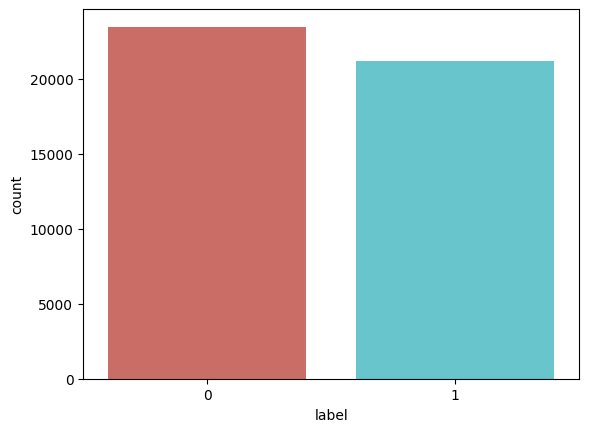

In [ ]:
def create_distribution(dataFile):
    return sns.countplot(x='label', data=dataFile, palette='hls')

create_distribution(df)

df['label'].value_counts()

/tmp/ipykernel_451/2389525981.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Year', data=df, order=df['Year'].value_counts().index, palette='Set1')


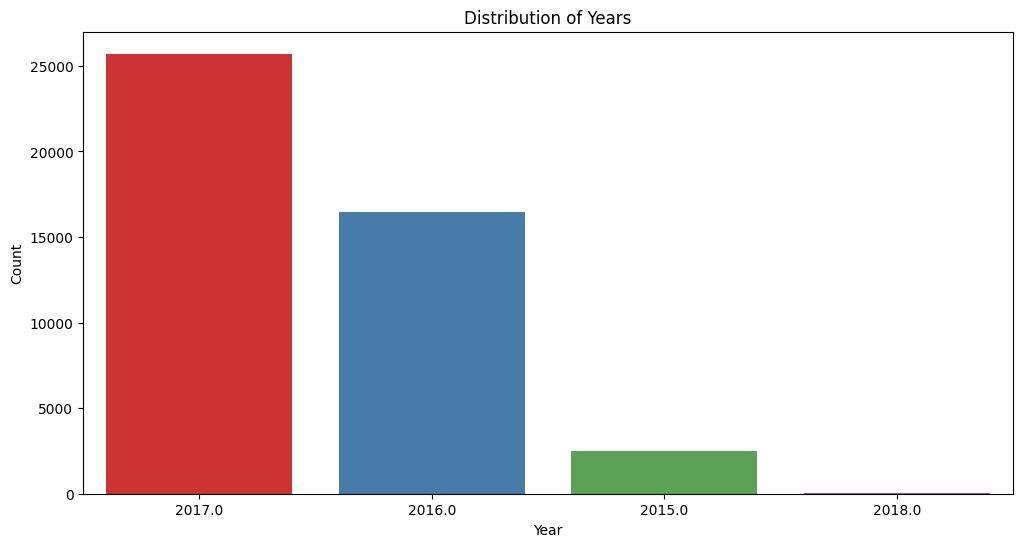

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Year', data=df, order=df['Year'].value_counts().index, palette='Set1')
plt.title('Distribution of Years')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

/tmp/ipykernel_451/285797254.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Month', data=df, order=df['Month'].value_counts().index, palette='Set2')


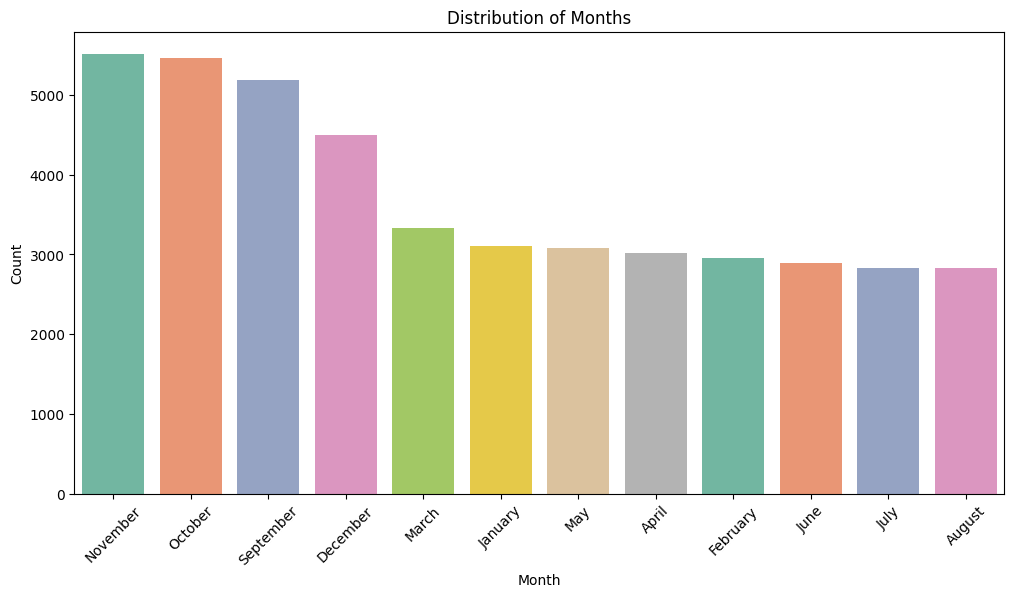

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Month', data=df, order=df['Month'].value_counts().index, palette='Set2')
plt.title('Distribution of Months')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_451/2194607429.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='subject', data=df, order=df['subject'].value_counts().index, palette='Set2')


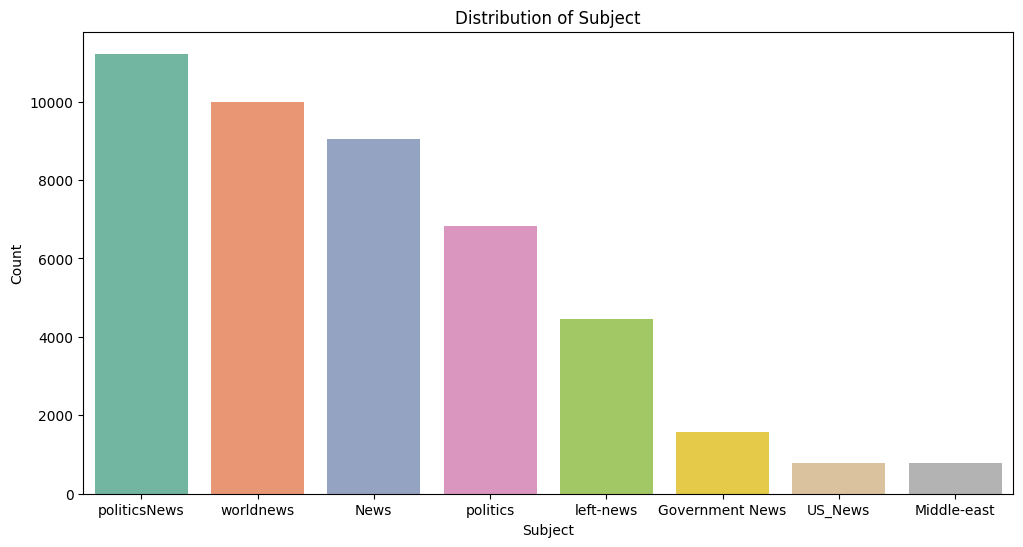

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='subject', data=df, order=df['subject'].value_counts().index, palette='Set2')
plt.title('Distribution of Subject')
plt.xlabel('Subject')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

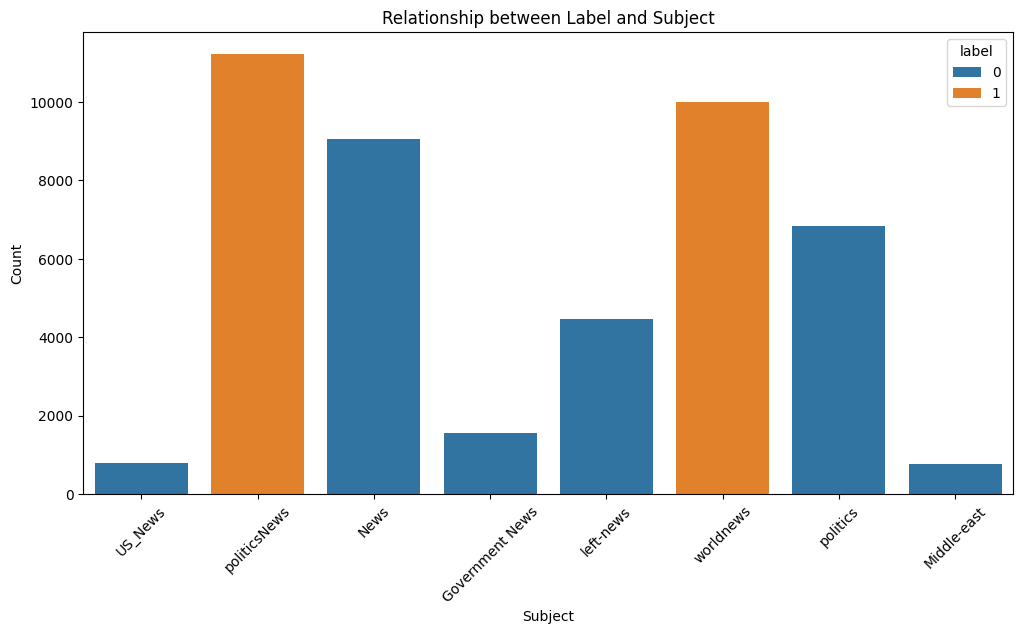

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='subject', hue='label', data=df)
plt.title('Relationship between Label and Subject')
plt.xlabel('Subject')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

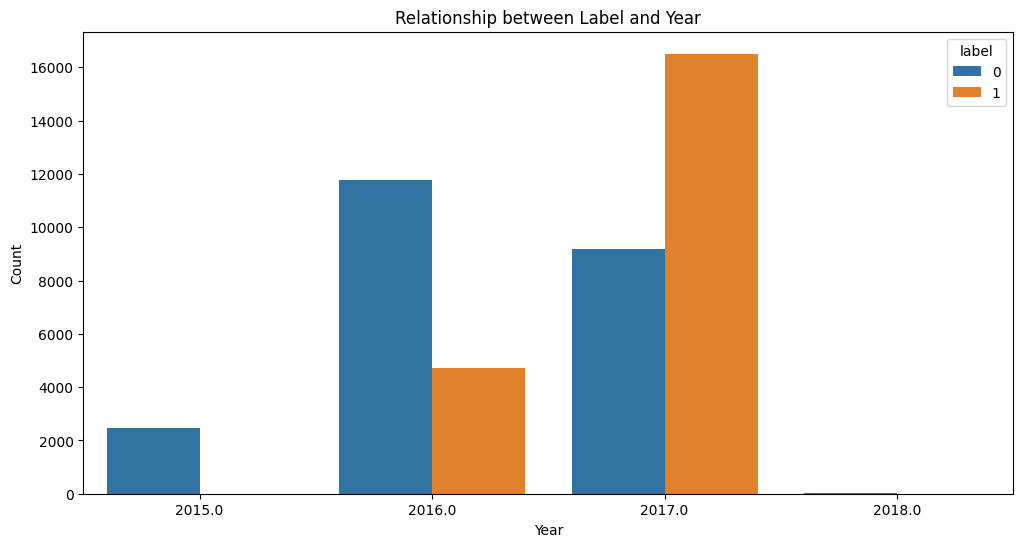

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Year', hue='label', data=df)
plt.title('Relationship between Label and Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

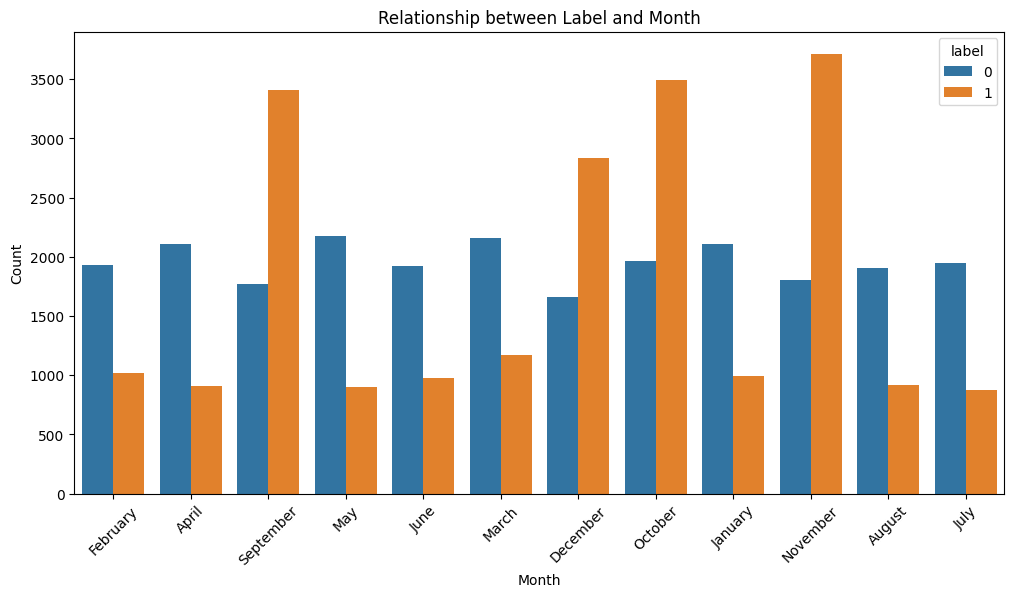

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Month', hue='label', data=df)
plt.title('Relationship between Label and Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

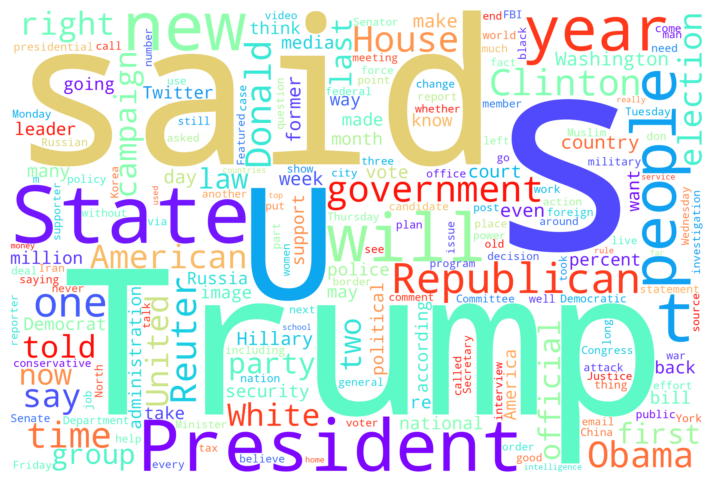

In [ ]:
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
text = " ".join(df['text'].astype(str))


wordcloud = WordCloud(width=3000, height=2000, random_state=1, background_color='white', colormap='rainbow', collocations=False, stopwords=STOPWORDS).generate(text)

# Plot
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [ ]:
import re
import nltk
import string

# Download required NLTK resources
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Preload stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Precompile regex patterns for speed
url_pattern = re.compile(r'http\S+|www\S+')
mention_pattern = re.compile(r'@\w+')
hashtag_pattern = re.compile(r'#\w+')
non_alpha_pattern = re.compile(r'[^a-zA-Z\s]')  # keep only letters and spaces
multi_space_pattern = re.compile(r'\s+')

def preprocess(text):
    text = str(text)  # Ensure text is string
    text = url_pattern.sub('', text)       # remove URLs
    text = mention_pattern.sub('', text)   # remove @mentions
    text = hashtag_pattern.sub('', text)   # remove hashtags
    text = non_alpha_pattern.sub(' ', text) # remove non-letters
    text = multi_space_pattern.sub(' ', text) # remove extra spaces
    text = text.lower().strip()  # lowercase & strip

    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]

    return ' '.join(tokens)

# Apply preprocessing
df['text'] = df['text'].apply(preprocess)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
fake.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [ ]:
true.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adadelta, Adam,SGD
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

In [ ]:
# feature engineering & training split
from sklearn.model_selection import train_test_split

x = df['text'].values   # feature
y = df['label'].values    # target

# train & validation split [80-20]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state= 42)

# view
print(f"Training records: {x_train.shape[0]} | Testing records: {x_test.shape[0]}")

Training records: 35751 | Testing records: 8938


In [ ]:
max_word = 30000
max_len = 400

In [ ]:
tokenizer = Tokenizer(num_words=max_word)
tokenizer.fit_on_texts(x_train) # Fit only on training data
sequences_train = tokenizer.texts_to_sequences(x_train)
sequences_test = tokenizer.texts_to_sequences(x_test)
padded_train = pad_sequences(sequences_train, maxlen=max_len)
padded_test = pad_sequences(sequences_test, maxlen=max_len)

In [ ]:
padded_train

array([[    0,     0,     0, ...,    83,  1047,  1128],
       [    0,     0,     0, ...,    60,    83,  5620],
       [  375,  1807,  3243, ...,   327,   375,  1807],
       ...,
       [    0,     0,     0, ...,    83,  4569,   122],
       [    0,     0,     0, ...,  1487,    83, 26779],
       [    0,     0,     0, ...,    60,    83,  2967]], dtype=int32)

In [ ]:
model = Sequential()
model.add(Embedding(max_word, 32, input_length = max_len))
model.add(SimpleRNN(32))
model.add(Dense(1, activation="sigmoid"))

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# training params
import gc
from tqdm.keras import TqdmCallback
es = keras.callbacks.EarlyStopping(monitor='val_loss', mode='min',verbose=0, patience=3)

# for re-runs
gc.collect()
keras.backend.clear_session()

# train model
hist = model.fit(x=padded_train,
                 y=y_train,
                 epochs=10,
                 shuffle=True,
                 validation_data=(padded_test,y_test),
                 verbose=0,
                 callbacks=[TqdmCallback(verbose=0),es])

0epoch [00:00, ?epoch/s]

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

pred = (model.predict(padded_test) > 0.5).astype('int32')
# classification report
print(classification_report(y_test, pred))
# accuracy score
acc_score = '{:.2%}'.format(accuracy_score(y_test, pred))
print(f"\nAccuracy Score: {acc_score}")

280/280 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      4652
           1       0.98      0.98      0.98      4286

    accuracy                           0.98      8938
   macro avg       0.98      0.98      0.98      8938
weighted avg       0.98      0.98      0.98      8938


Accuracy Score: 98.12%


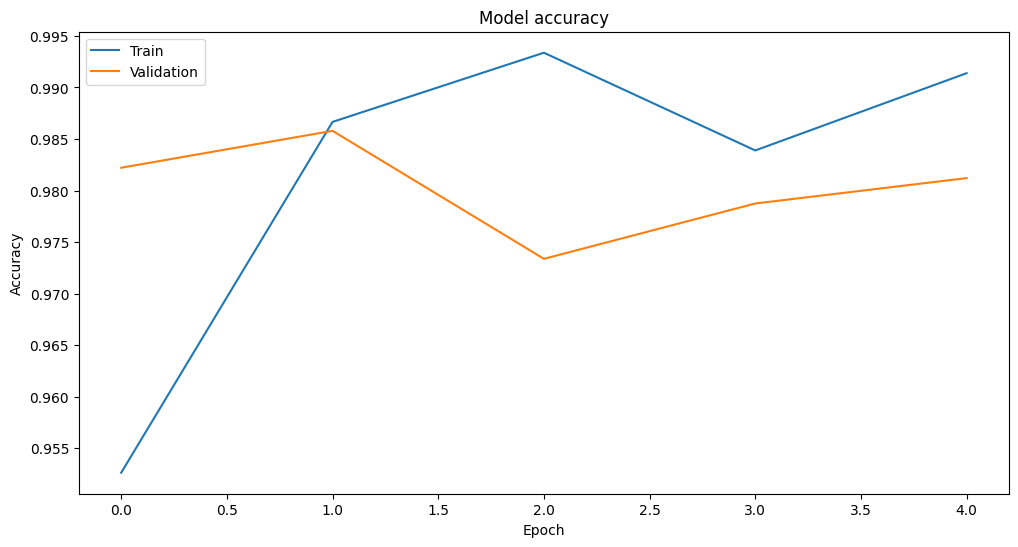

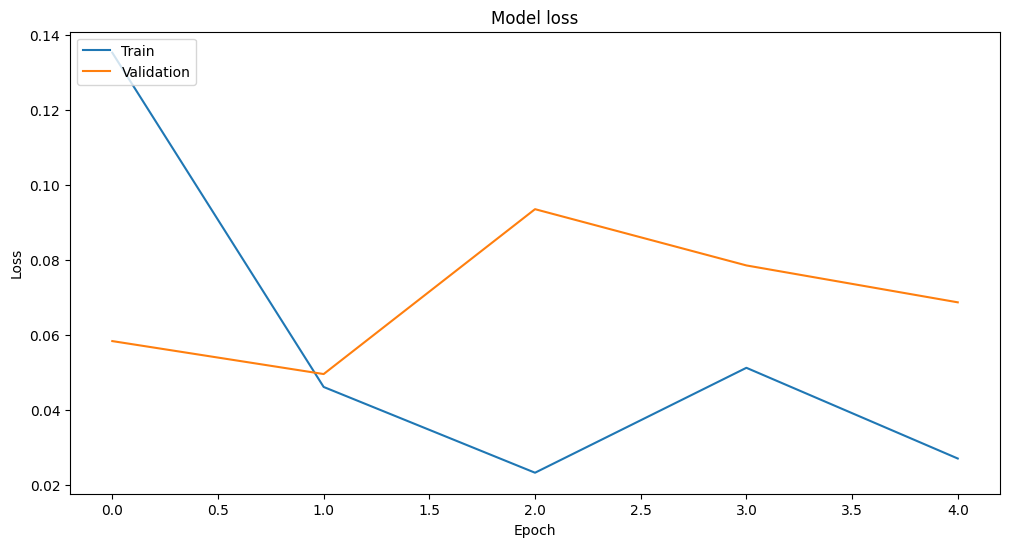

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adadelta, Adam,SGD
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, LSTM, Dropout

embedding_vector_features=100 # We will have a vector representation to text with only 100 features

model=Sequential()
model.add(Embedding(len(tokenizer.word_index)+1, embedding_vector_features, input_length=max_len))
model.add(LSTM(100))
model.add(Dropout(0.2))

# LSTM layer (output) is fully connected to the Dense layer
model.add(Dense(1,activation='sigmoid'))
model.compile(loss='binary_crossentropy',optimizer=Adam(learning_rate=0.0001),metrics=['accuracy'])

print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# training params
import gc
from tqdm.keras import TqdmCallback
es = keras.callbacks.EarlyStopping(monitor='val_loss', mode='min',verbose=0, patience=3)

# for re-runs
gc.collect()
keras.backend.clear_session()

# train model
hist = model.fit(x=padded_train,
                 y=y_train,
                 epochs=10,
                 shuffle=True,
                 validation_data=(padded_test,y_test),
                 verbose=0,
                 callbacks=[TqdmCallback(verbose=0),es])

0epoch [00:00, ?epoch/s]

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

pred = (model.predict(padded_test) > 0.5).astype('int32')
# classification report
print(classification_report(y_test, pred))
# accuracy score
acc_score = '{:.2%}'.format(accuracy_score(y_test, pred))
print(f"\nAccuracy Score: {acc_score}")

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Input string of boolean values
input_str = "true false false true false false"

# Convert string to a list of boolean values
# Assuming 'true' means True and 'false' means False
boolean_values = [s.lower() == 'true' for s in input_str.split()]

# Split into y_true and y_pred (assuming first half is true, second is pred)
# This assumes an even number of values, adjust if your actual data differs
half_length = len(boolean_values) // 2
y_true = boolean_values[:half_length]
y_pred = boolean_values[half_length:]

# Calculate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("True Labels (y_true):")
print(y_true)
print("Predicted Labels (y_pred):")
print(y_pred)
print("\nConfusion Matrix:")
print(cm)

# For better interpretation, you can label the matrix:
# Rows: Actual (True), Columns: Predicted (False, True)
# [[TN, FP],
#  [FN, TP]]
# In this example, if the labels are binary (e.g., 0 and 1, or False and True),
# the matrix is typically ordered as:
# [[True Negatives, False Positives],
#  [False Negatives, True Positives]]
print("\nInterpretation (for binary classification, e.g., False=0, True=1):")
print("[[True Negatives, False Positives], ")
print(" [False Negatives, True Positives]]")

In [ ]:
# Save trained model
model.save("fake_news_model.h5")

# Save tokenizer
import pickle
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [ ]:
from google.colab import files
files.download("fake_news_model.h5")
files.download("tokenizer.pkl")